# 🔬 Thin Film Hardness Prediction using Artificial Neural Networks

**Author:** Veena Sahu (@Veena Sahu)

---

## Project Overview

This project uses an **Artificial Neural Network (ANN)** to predict the **Vickers Hardness (VHN)** of thin film multi-principal element alloys (MPEAs). The model is trained on a curated dataset of 218 alloys using physically meaningful features derived from alloy composition and thermodynamic properties.

### Key Highlights
- **K-Fold Cross-Validation** (K=5) for robust model evaluation
- **Multiple training runs** with best-model selection for reliable convergence
- **Comprehensive visualizations** — loss curves, error distributions, actual vs predicted plots

### Features Used
| Feature | Description |
|---------|-------------|
| `R_cov_delta` | Covalent radius mismatch |
| `G_delta` | Shear modulus mismatch |
| `VEC` | Valence electron concentration |
| `E_delta` | Young's modulus mismatch |
| `H_chem` | Chemical enthalpy |
| `H_el` | Elastic strain energy |

---
## 1. Imports & Configuration

In [1]:
# ── Standard Libraries ──
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Plot styling ──
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

print('All imports successful ✓')

All imports successful ✓


In [2]:
# ══════════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════════

CONFIG = {
    'project_name'          : 'ThinFilm_Hardness_ANN',
    'database'              : 'db_HEAs.csv',
    'target'                : 'VHN',
    'features'              : ['R_cov_delta', 'G_delta', 'VEC', 'E_delta', 'H_chem', 'H_el'],
    'hidden_layer_sizes'    : (20, 15, 10),
    'activation'            : 'relu',
    'solver'                : 'adam',
    'learning_rate_init'    : 0.02,
    'max_iter'              : 500,
    'n_restarts'            : 5,        # number of restarts to pick best model
    'k_folds'               : 5,
    'random_state'          : 1,
}

print('Configuration loaded ✓')
for k, v in CONFIG.items():
    print(f'  {k:28s}: {v}')

Configuration loaded ✓
  project_name                : ThinFilm_Hardness_ANN
  database                    : db_HEAs.csv
  target                      : VHN
  features                    : ['R_cov_delta', 'G_delta', 'VEC', 'E_delta', 'H_chem', 'H_el']
  hidden_layer_sizes          : (20, 15, 10)
  activation                  : relu
  solver                      : adam
  learning_rate_init          : 0.02
  max_iter                    : 500
  n_restarts                  : 5
  k_folds                     : 5
  random_state                : 1


---
## 2. Data Loading & Exploration

In [3]:
# ── Load the dataset ──
db = pd.read_csv(CONFIG['database'], encoding='latin-1')

# Keep only required columns
cols_needed = ['alloy_name', 'phases', CONFIG['target']] + CONFIG['features']
db = db[cols_needed]

# Drop rows with NaN in target or feature columns
db = db.dropna(axis='index', subset=[CONFIG['target']] + CONFIG['features'])
db = db.reset_index(drop=True)

print(f'Dataset shape: {db.shape}')
print(f'Number of alloys: {len(db)}')
print(f'Target column: {CONFIG["target"]}')
db.head(10)

Dataset shape: (218, 9)
Number of alloys: 218
Target column: VHN


,alloy_name,phases,VHN,R_cov_delta,G_delta,VEC,E_delta,H_chem,H_el
0,Al1.8CoCrCuFe,FCC + BCC,557.0,0.065928,0.651824,0.554598,0.599158,0.627285,0.279585
1,AlCoCrCuFeNi,FCC + BCC,439.0,0.123787,0.507946,0.699074,0.489137,0.673670,0.205536
2,Al22.5Cu20Fe15Ni20Ti22.5,FCC,516.0,0.632699,0.681679,0.579861,0.638642,0.258663,0.479585
3,Co1.5CrFeNi1.5Ti,FCC + Im,654.0,0.621023,0.343857,0.687500,0.341835,0.408731,0.384775
4,NbTaTiVW,BCC+HCP,447.0,0.113213,0.964258,0.305556,0.965055,0.726057,0.155017
5,CoFeMoNi1.6V,FCC + Im,520.0,0.725283,0.466767,0.702381,0.408092,0.576808,0.381315
6,AlCrCuFeNi,FCC + BCC,418.5,0.110892,0.555298,0.666667,0.534788,0.684857,0.220069
7,Al1.125CuFe0.75NiTi1.125,FCC,516.0,0.632699,0.681679,0.579861,0.638642,0.258663,0.479585
8,AlCoCrFeMo0.5Ni0.5,BCC + Im,708.0,0.403750,0.602475,0.555556,0.611057,0.517599,0.367474
9,Al1.5CoCrFeNi,BCC,467.7,0.139031,0.575298,0.558081,0.568540,0.428922,0.313495


In [4]:
# ── Descriptive Statistics ──
db[[CONFIG['target']] + CONFIG['features']].describe().round(4)

,VHN,R_cov_delta,G_delta,VEC,E_delta,H_chem,H_el
count,218.0000,218.0000,218.0000,218.0000,218.0000,218.0000,218.0000
mean,476.1174,0.3582,0.5352,0.5647,0.5151,0.5811,0.2939
std,182.0695,0.2556,0.1986,0.1929,0.1914,0.1783,0.1947
min,109.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,344.7500,0.1377,0.4309,0.4698,0.3829,0.4827,0.1517
50%,493.5000,0.3042,0.5354,0.6167,0.5020,0.5821,0.2581
75%,601.5000,0.5451,0.6661,0.6914,0.6380,0.6964,0.3848
max,905.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


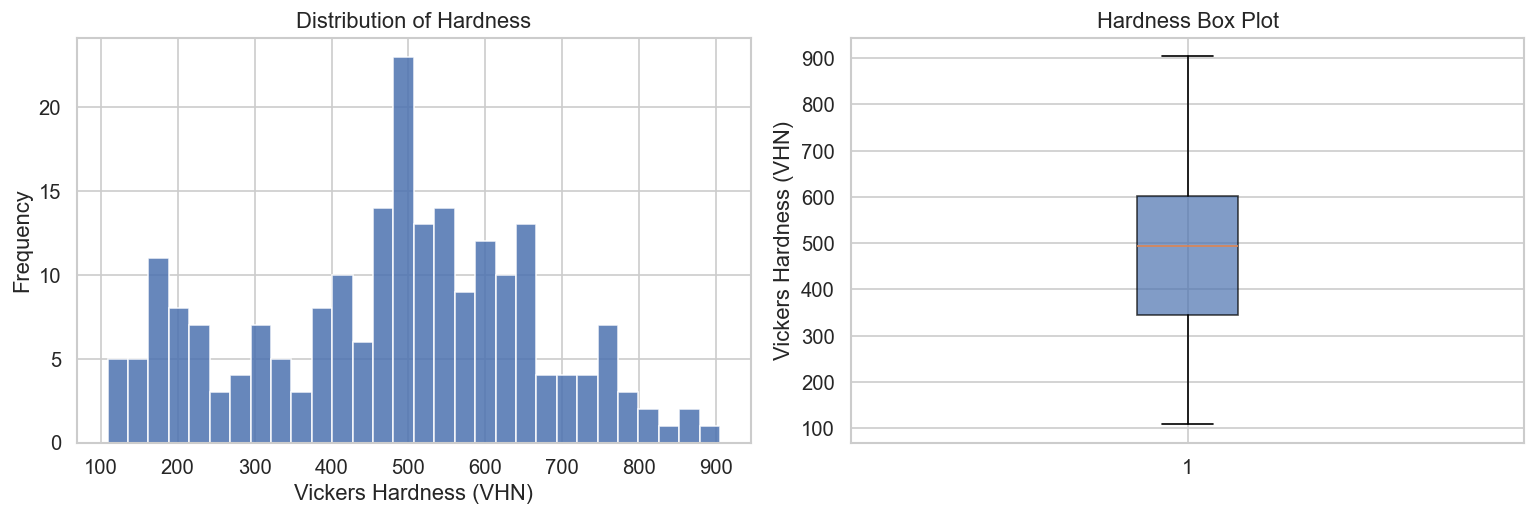

In [5]:
# ── Target Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(db[CONFIG['target']], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Vickers Hardness (VHN)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Hardness')

axes[1].boxplot(db[CONFIG['target']], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[1].set_ylabel('Vickers Hardness (VHN)')
axes[1].set_title('Hardness Box Plot')

plt.tight_layout()
plt.show()

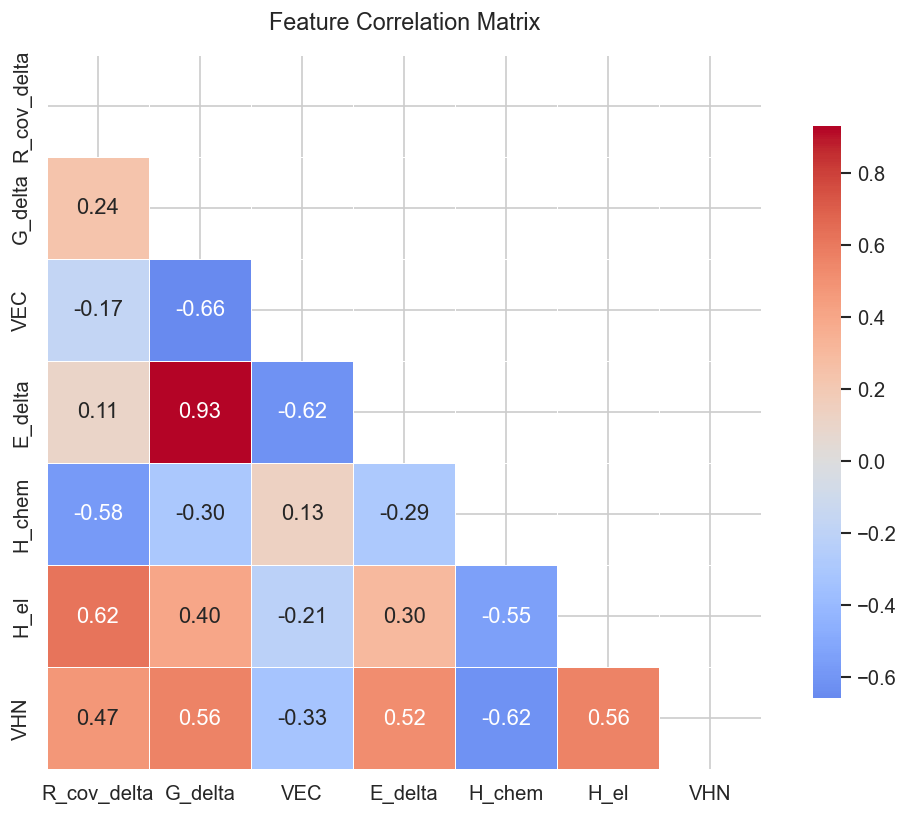

In [6]:
# ── Feature Correlation Heatmap ──
corr_cols = CONFIG['features'] + [CONFIG['target']]
corr_matrix = db[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

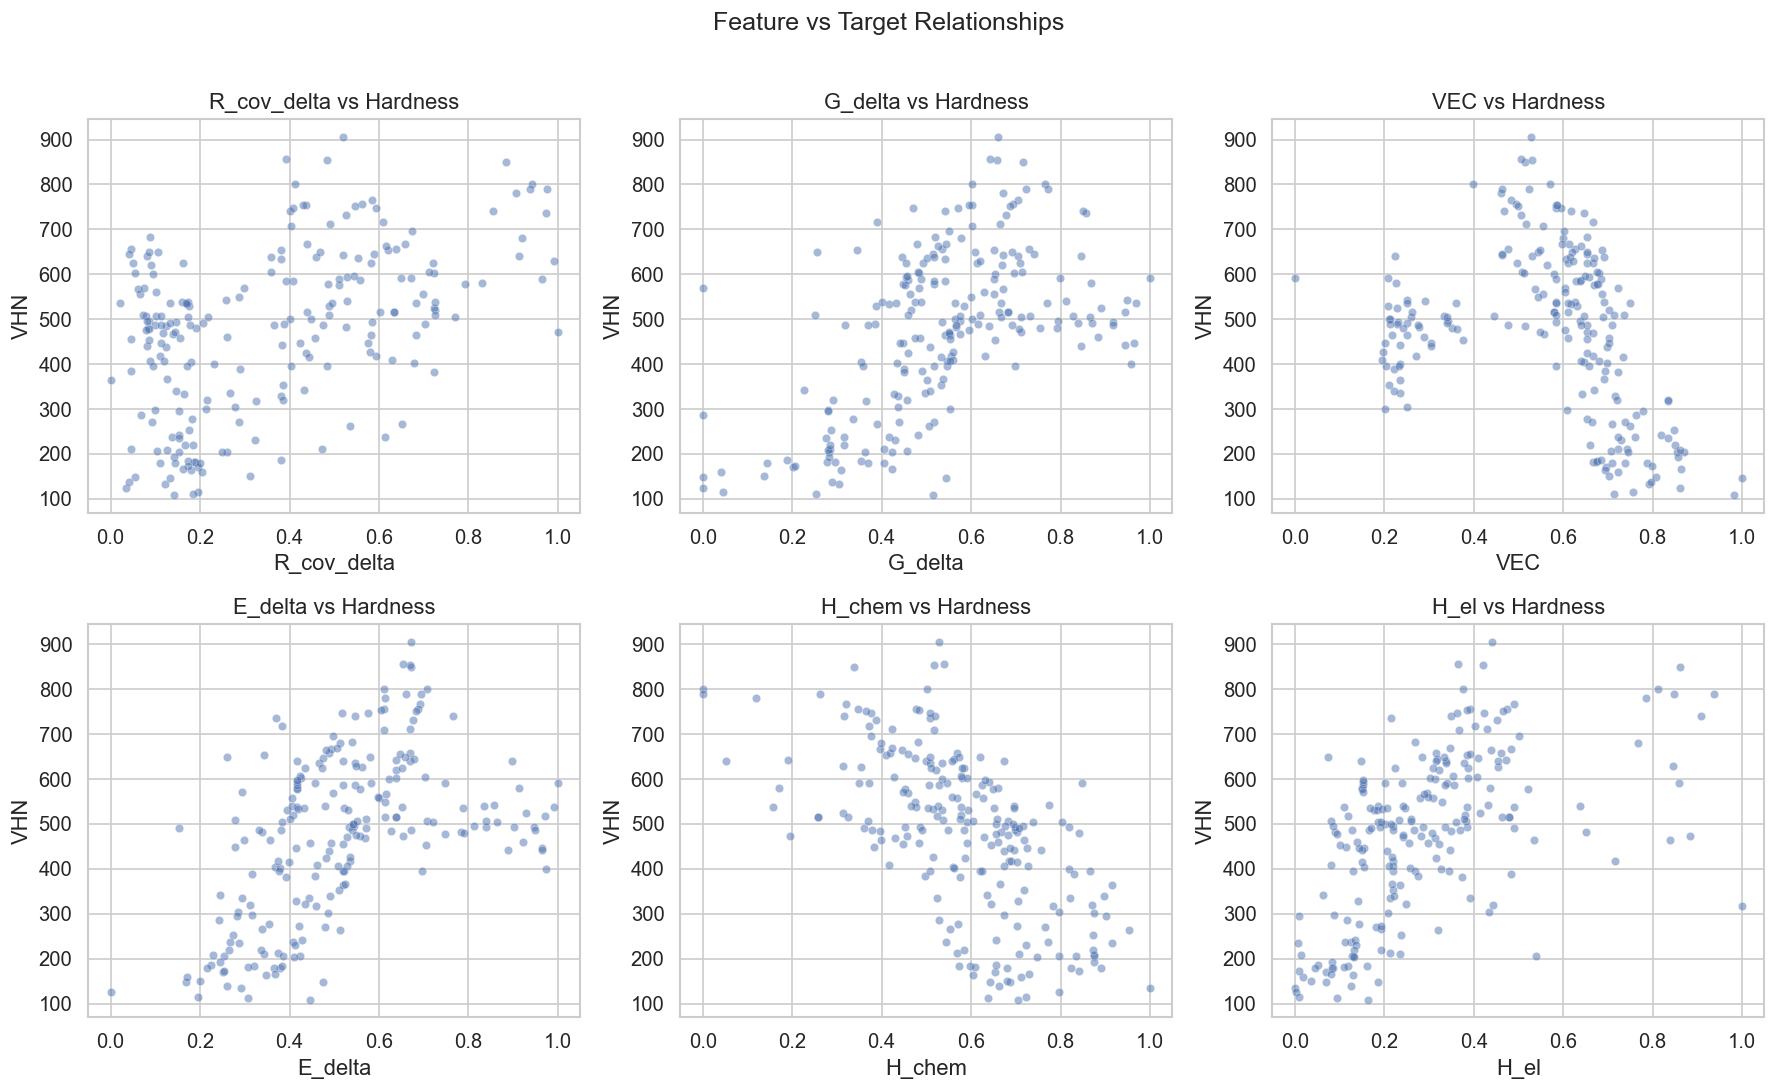

In [7]:
# ── Pairwise Feature Scatter (vs Target) ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(CONFIG['features']):
    axes[i].scatter(db[feat], db[CONFIG['target']], alpha=0.5, s=25, color='#4C72B0', edgecolors='white', linewidth=0.3)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('VHN')
    axes[i].set_title(f'{feat} vs Hardness')

plt.suptitle('Feature vs Target Relationships', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

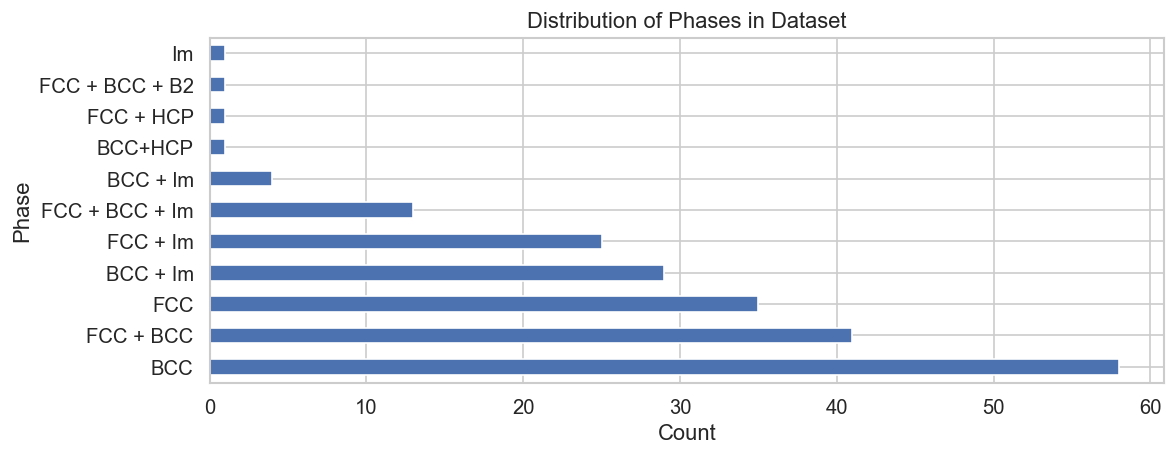

In [8]:
# ── Phase Distribution ──
phase_counts = db['phases'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
phase_counts.plot(kind='barh', color='#4C72B0', edgecolor='white', ax=ax)
ax.set_xlabel('Count')
ax.set_ylabel('Phase')
ax.set_title('Distribution of Phases in Dataset')
plt.tight_layout()
plt.show()

---
## 3. Data Preparation

In [9]:
# ── Extract features (X) and target (Y) ──
X = db[CONFIG['features']].values
Y = db[CONFIG['target']].values

# Build labels for result tables
phases = np.array(db['phases']).astype('str')
labels = (db['alloy_name'] + ' (' + phases + ')').values

# Shuffle dataset
X, Y, labels = shuffle(X, Y, labels, random_state=CONFIG['random_state'])

print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}')
print(f'Labels:  {labels.shape}')

X shape: (218, 6)
Y shape: (218,)
Labels:  (218,)


---
## 4. ANN Model Definition

In [10]:
def build_ann_model(config, random_state=42):
    """
    Build an MLPRegressor (ANN) for hardness prediction.

    Parameters
    ----------
    config : dict
        Configuration dictionary containing model hyperparameters.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    sklearn.neural_network.MLPRegressor
        Configured (untrained) MLP model.
    """
    model = MLPRegressor(
        hidden_layer_sizes=config['hidden_layer_sizes'],
        activation=config['activation'],
        solver=config['solver'],
        learning_rate_init=config['learning_rate_init'],
        max_iter=config['max_iter'],
        random_state=random_state,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        verbose=False,
    )
    return model


print('Model architecture:')
print(f'  Input:   {len(CONFIG["features"])} features')
print(f'  Hidden:  {CONFIG["hidden_layer_sizes"]}')
print(f'  Output:  1 (Hardness)')
print(f'  Solver:  {CONFIG["solver"]}, lr={CONFIG["learning_rate_init"]}')
print(f'  Max iterations: {CONFIG["max_iter"]}')
print('Model builder ready ✓')

Model architecture:
  Input:   6 features
  Hidden:  (20, 15, 10)
  Output:  1 (Hardness)
  Solver:  adam, lr=0.02
  Max iterations: 500
Model builder ready ✓


---
## 5. K-Fold Cross-Validation Training

In [11]:
# ── Create results directory ──
results_dir    = CONFIG['project_name']
pred_save_dir  = os.path.join(results_dir, 'predictions')
perf_save_dir  = os.path.join(results_dir, 'performance')

for d in [results_dir, pred_save_dir, perf_save_dir]:
    os.makedirs(d, exist_ok=True)

print(f'Results will be saved to: {results_dir}/')

Results will be saved to: ThinFilm_Hardness_ANN/


In [12]:
# ══════════════════════════════════════════════════════════════════
#  K-Fold Cross-Validation Training Loop
# ══════════════════════════════════════════════════════════════════

K = CONFIG['k_folds']
L = len(Y)
K_L = L // K  # size of each validation fold
n_restarts = CONFIG['n_restarts']

# Storage for all results
all_fold_perf = []
all_predictions = []  # (actual, predicted, fold)
all_loss_curves = {}  # fold -> loss_curve

print(f'Running {K}-fold cross-validation')
print(f'  Dataset size: {L} | Fold size: {K_L} | Restarts per fold: {n_restarts}')
print('=' * 65)

for Kn in range(K):
    print(f'\n▶ Fold {Kn+1}/{K}')
    print('-' * 45)

    # ── Split data ──
    start_idx = Kn * K_L
    end_idx   = start_idx + K_L

    Kx_test  = X[start_idx:end_idx]
    Ky_test  = Y[start_idx:end_idx]
    Kx_train = np.delete(X, np.s_[start_idx:end_idx], axis=0)
    Ky_train = np.delete(Y, np.s_[start_idx:end_idx], axis=0)
    K_labels = labels[start_idx:end_idx]

    # ── Scale features ──
    scaler = StandardScaler()
    Kx_train_s = scaler.fit_transform(Kx_train)
    Kx_test_s  = scaler.transform(Kx_test)

    print(f'  Train: {Kx_train_s.shape[0]} samples | Test: {Kx_test_s.shape[0]} samples')

    # ── Train multiple models, keep best ──
    best_model = None
    best_mae   = np.inf

    for r in range(n_restarts):
        model = build_ann_model(CONFIG, random_state=r * 42 + Kn)
        model.fit(Kx_train_s, Ky_train)

        pred_val = model.predict(Kx_test_s)
        mae_val  = mean_absolute_error(Ky_test, pred_val)

        if mae_val < best_mae:
            best_mae   = mae_val
            best_model = model

        print(f'    Run {r+1}/{n_restarts} — Val MAE: {mae_val:.2f}', end='')
        print(' ★ best' if mae_val == best_mae else '')

    # ── Record loss curve ──
    all_loss_curves[Kn] = best_model.loss_curve_

    # ── Final predictions with best model ──
    pred_train = best_model.predict(Kx_train_s)
    pred_test  = best_model.predict(Kx_test_s)

    # Metrics
    MAE_train = mean_absolute_error(Ky_train, pred_train)
    MAE_test  = mean_absolute_error(Ky_test, pred_test)
    RMSE_test = mean_squared_error(Ky_test, pred_test) ** 0.5
    r2_test   = r2_score(Ky_test, pred_test)

    fold_perf = {
        'Fold': f'K{Kn+1}',
        'MAE_train': MAE_train,
        'MAE_test': MAE_test,
        'RMSE_test': RMSE_test,
        'R2_test': r2_test,
        'Iterations': best_model.n_iter_,
    }
    all_fold_perf.append(fold_perf)

    # Save predictions
    pred_df = pd.DataFrame({
        'Alloy': K_labels,
        'VHN_actual': Ky_test,
        'VHN_predicted': pred_test,
        'Error': pred_test - Ky_test,
        'Abs_Error': np.abs(pred_test - Ky_test),
        'Pct_Error': np.abs(pred_test - Ky_test) * 100 / Ky_test,
    })
    pred_df.to_csv(os.path.join(pred_save_dir, f'fold{Kn+1}_predictions.csv'), index=False)

    # Collect for combined plots
    for a, p in zip(Ky_test, pred_test):
        all_predictions.append({'actual': a, 'predicted': p, 'fold': f'K{Kn+1}'})

    print(f'  ✓ Fold {Kn+1} — MAE: {MAE_test:.2f} | RMSE: {RMSE_test:.2f} | R²: {r2_test:.4f}')

# Save combined performance
perf_summary = pd.DataFrame(all_fold_perf)
perf_summary.to_csv(os.path.join(perf_save_dir, 'fold_performance.csv'), index=False)

print('\n' + '=' * 65)
print('Training complete ✓')

Running 5-fold cross-validation
  Dataset size: 218 | Fold size: 43 | Restarts per fold: 5

▶ Fold 1/5
---------------------------------------------
  Train: 175 samples | Test: 43 samples
    Run 1/5 — Val MAE: 94.01 ★ best
    Run 2/5 — Val MAE: 103.77


    Run 3/5 — Val MAE: 84.82 ★ best
    Run 4/5 — Val MAE: 84.22 ★ best
    Run 5/5 — Val MAE: 103.75
  ✓ Fold 1 — MAE: 84.22 | RMSE: 106.79 | R²: 0.6298

▶ Fold 2/5
---------------------------------------------
  Train: 175 samples | Test: 43 samples


    Run 1/5 — Val MAE: 71.86 ★ best
    Run 2/5 — Val MAE: 63.74 ★ best


    Run 3/5 — Val MAE: 93.48
    Run 4/5 — Val MAE: 75.04


    Run 5/5 — Val MAE: 83.15
  ✓ Fold 2 — MAE: 63.74 | RMSE: 86.77 | R²: 0.7400

▶ Fold 3/5
---------------------------------------------
  Train: 175 samples | Test: 43 samples
    Run 1/5 — Val MAE: 89.19 ★ best


...

    Run 4/5 — Val MAE: 90.24
    Run 5/5 — Val MAE: 92.05
  ✓ Fold 3 — MAE: 88.07 | RMSE: 109.13 | R²: 0.6707

▶ Fold 4/5
---------------------------------------------
  Train: 175 samples | Test: 43 samples
    Run 1/5 — Val MAE: 80.31 ★ best


    Run 2/5 — Val MAE: 87.91
    Run 3/5 — Val MAE: 100.91


    Run 4/5 — Val MAE: 98.17
    Run 5/5 — Val MAE: 99.32
  ✓ Fold 4 — MAE: 80.31 | RMSE: 103.71 | R²: 0.6378

▶ Fold 5/5
---------------------------------------------
  Train: 175 samples | Test: 43 samples
    Run 1/5 — Val MAE: 121.63 ★ best


    Run 2/5 — Val MAE: 83.38 ★ best
    Run 3/5 — Val MAE: 63.79 ★ best


    Run 4/5 — Val MAE: 75.25
    Run 5/5 — Val MAE: 123.52
  ✓ Fold 5 — MAE: 63.79 | RMSE: 81.41 | R²: 0.8208

Training complete ✓


---
## 6. Results & Visualization

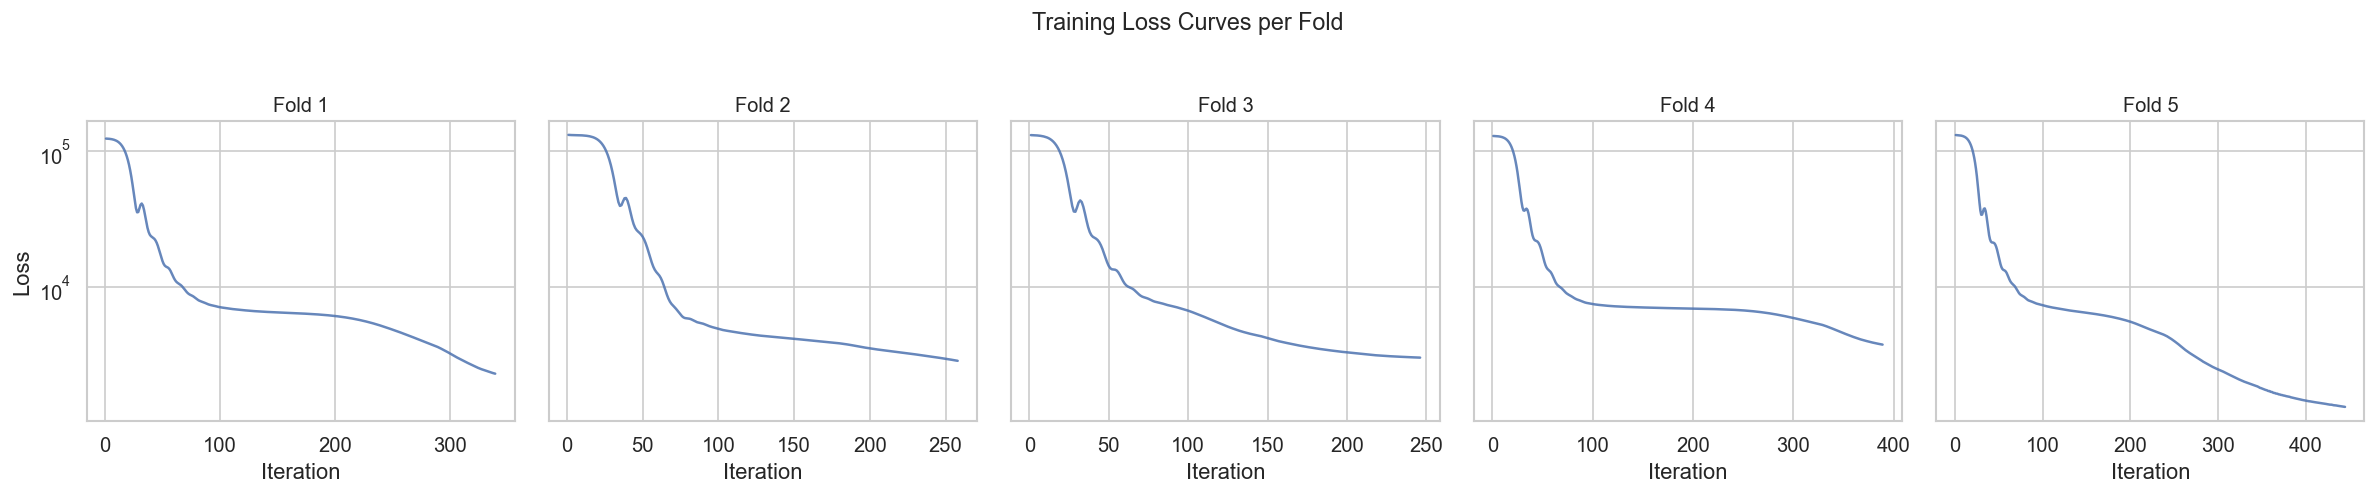

In [13]:
# ══════════════════════════════════════════════════════════════════
#  6a. Training Loss Curves (per fold)
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, K, figsize=(4 * K, 4), sharey=True)
if K == 1:
    axes = [axes]

for i in range(K):
    ax = axes[i]
    loss = all_loss_curves[i]
    ax.plot(range(1, len(loss) + 1), loss, color='#4C72B0', alpha=0.85, linewidth=1.5)
    ax.set_title(f'Fold {i+1}', fontsize=12)
    ax.set_xlabel('Iteration')
    if i == 0:
        ax.set_ylabel('Loss')
    ax.set_yscale('log')

fig.suptitle('Training Loss Curves per Fold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

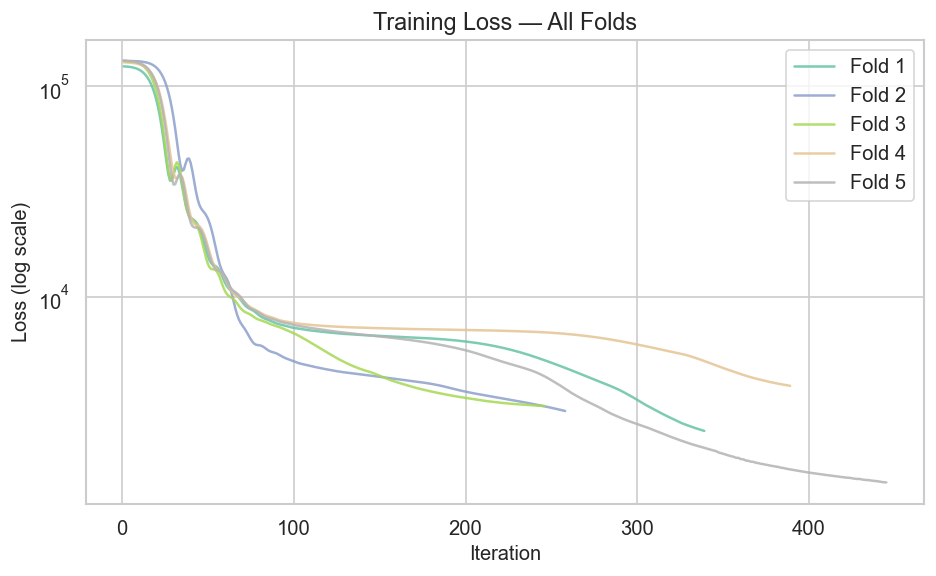

In [14]:
# ══════════════════════════════════════════════════════════════════
#  6b. Combined Loss Curves (overlay)
# ══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Set2(np.linspace(0, 1, K))

for i in range(K):
    loss = all_loss_curves[i]
    ax.plot(range(1, len(loss) + 1), loss, color=colors[i], alpha=0.85,
            linewidth=1.5, label=f'Fold {i+1}')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Training Loss — All Folds', fontsize=14)
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

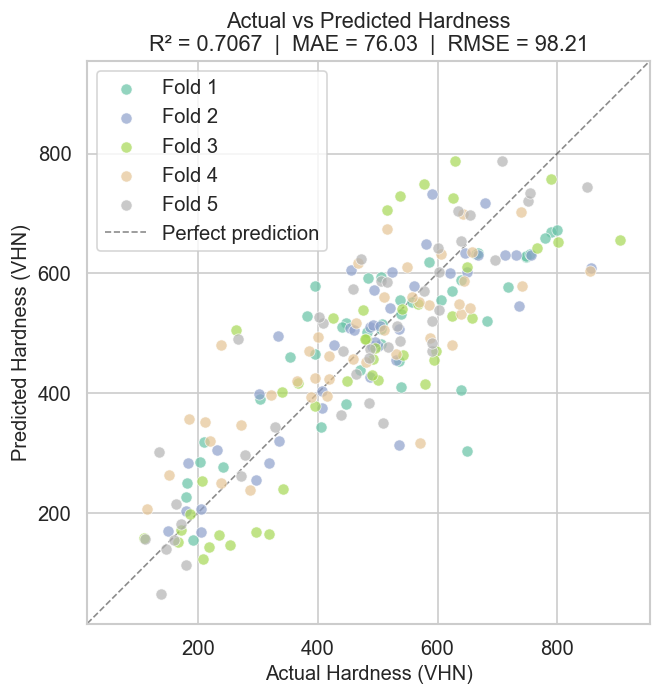

In [15]:
# ══════════════════════════════════════════════════════════════════
#  6c. Actual vs Predicted Scatter Plot (all folds combined)
# ══════════════════════════════════════════════════════════════════

pred_all = pd.DataFrame(all_predictions)

fig, ax = plt.subplots(figsize=(7, 6))
colors_map = plt.cm.Set2(np.linspace(0, 1, K))

for i in range(K):
    fold_data = pred_all[pred_all['fold'] == f'K{i+1}']
    ax.scatter(fold_data['actual'], fold_data['predicted'],
               alpha=0.7, s=45, color=colors_map[i], edgecolors='white',
               linewidth=0.5, label=f'Fold {i+1}', zorder=3)

# Perfect prediction line
all_vals = list(pred_all['actual']) + list(pred_all['predicted'])
lims = [min(all_vals) - 50, max(all_vals) + 50]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)

# Overall metrics
overall_r2  = r2_score(pred_all['actual'], pred_all['predicted'])
overall_mae = mean_absolute_error(pred_all['actual'], pred_all['predicted'])
overall_rmse = mean_squared_error(pred_all['actual'], pred_all['predicted']) ** 0.5

ax.set_xlabel('Actual Hardness (VHN)', fontsize=12)
ax.set_ylabel('Predicted Hardness (VHN)', fontsize=12)
ax.set_title(f'Actual vs Predicted Hardness\nR² = {overall_r2:.4f}  |  MAE = {overall_mae:.2f}  |  RMSE = {overall_rmse:.2f}', fontsize=13)
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

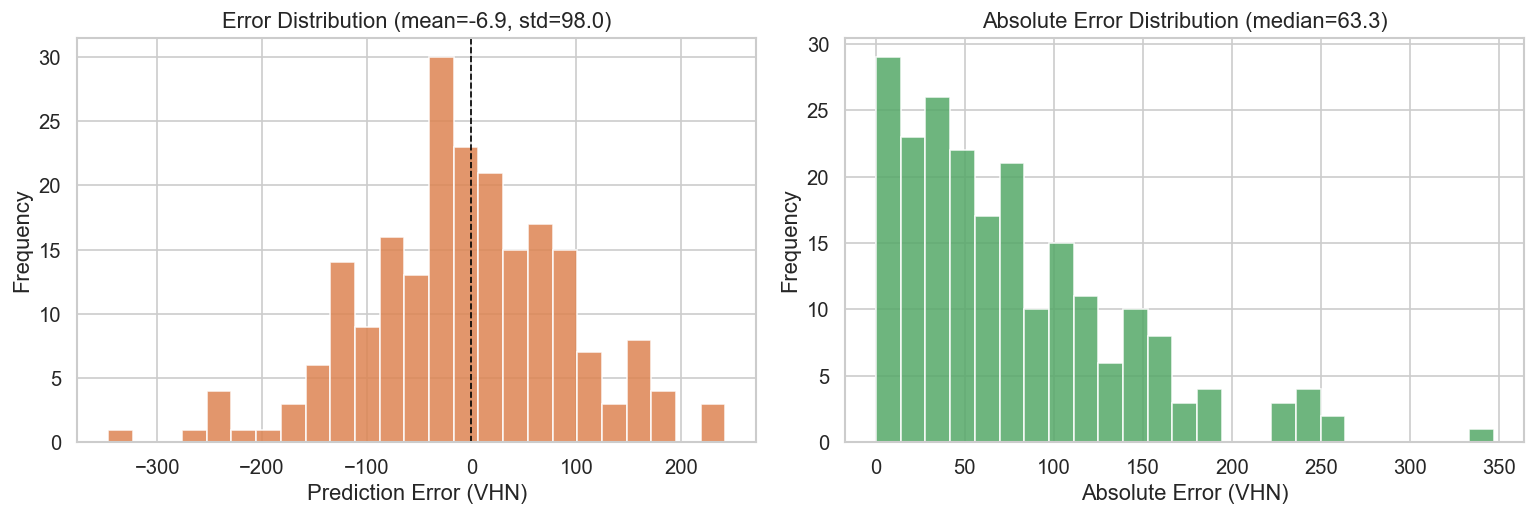

In [16]:
# ══════════════════════════════════════════════════════════════════
#  6d. Error Distribution
# ══════════════════════════════════════════════════════════════════

errors = pred_all['predicted'].values - pred_all['actual'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(errors, bins=25, color='#DD8452', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Prediction Error (VHN)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Error Distribution (mean={np.mean(errors):.1f}, std={np.std(errors):.1f})')

axes[1].hist(np.abs(errors), bins=25, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Absolute Error (VHN)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Absolute Error Distribution (median={np.median(np.abs(errors)):.1f})')

plt.tight_layout()
plt.show()

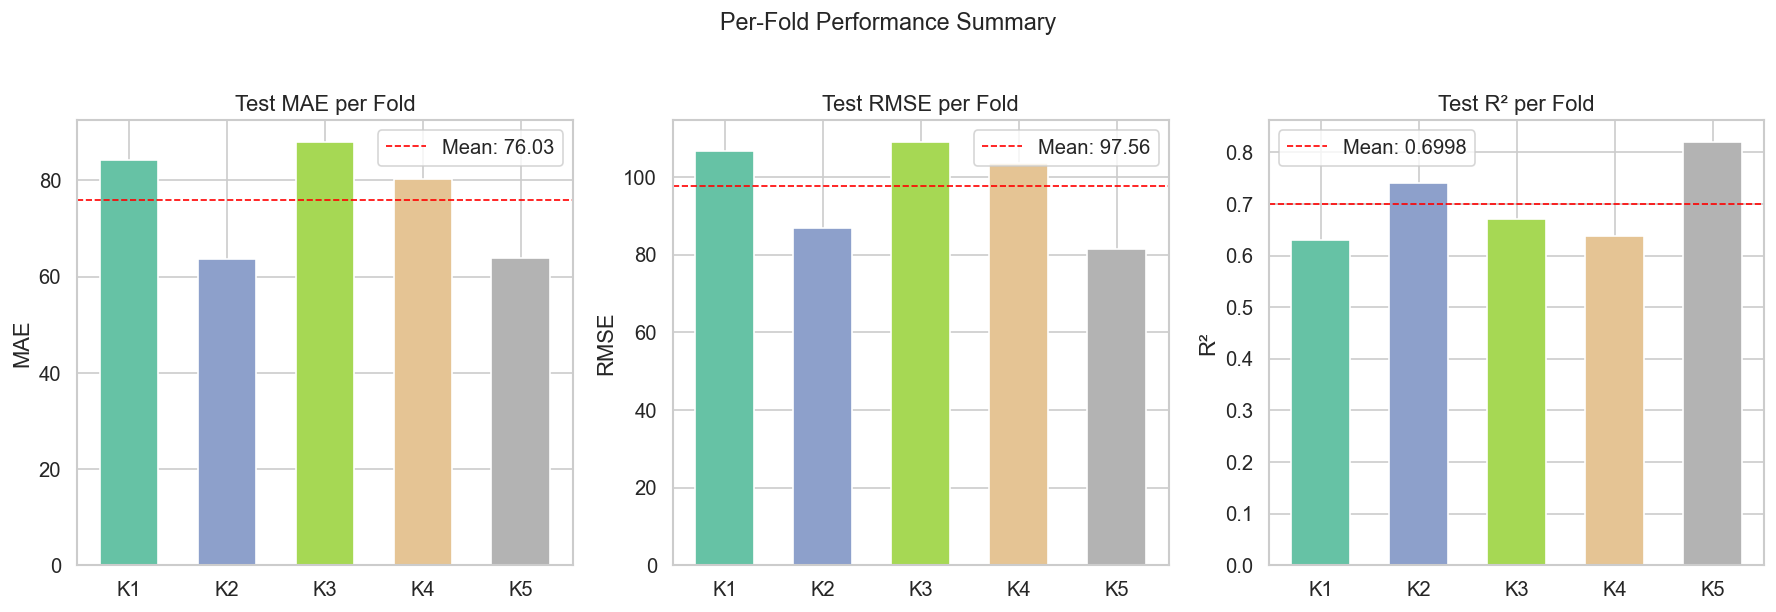

In [17]:
# ══════════════════════════════════════════════════════════════════
#  6e. Per-Fold Performance Bar Chart
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

folds = perf_summary['Fold'].values
x_pos = np.arange(len(folds))
bar_colors = plt.cm.Set2(np.linspace(0, 1, K))

# MAE
axes[0].bar(x_pos, perf_summary['MAE_test'], color=bar_colors, edgecolor='white', width=0.6)
axes[0].axhline(perf_summary['MAE_test'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {perf_summary["MAE_test"].mean():.2f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(folds)
axes[0].set_ylabel('MAE')
axes[0].set_title('Test MAE per Fold')
axes[0].legend()

# RMSE
axes[1].bar(x_pos, perf_summary['RMSE_test'], color=bar_colors, edgecolor='white', width=0.6)
axes[1].axhline(perf_summary['RMSE_test'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {perf_summary["RMSE_test"].mean():.2f}')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(folds)
axes[1].set_ylabel('RMSE')
axes[1].set_title('Test RMSE per Fold')
axes[1].legend()

# R²
axes[2].bar(x_pos, perf_summary['R2_test'], color=bar_colors, edgecolor='white', width=0.6)
axes[2].axhline(perf_summary['R2_test'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {perf_summary["R2_test"].mean():.4f}')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(folds)
axes[2].set_ylabel('R²')
axes[2].set_title('Test R² per Fold')
axes[2].legend()

plt.suptitle('Per-Fold Performance Summary', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# ══════════════════════════════════════════════════════════════════
#  6f. Performance Summary Table
# ══════════════════════════════════════════════════════════════════

print('\n📊 Final Performance per Fold')
print('=' * 75)

display_df = perf_summary.copy()
display_df['MAE_train'] = display_df['MAE_train'].map('{:.2f}'.format)
display_df['MAE_test']  = display_df['MAE_test'].map('{:.2f}'.format)
display_df['RMSE_test'] = display_df['RMSE_test'].map('{:.2f}'.format)
display_df['R2_test']   = display_df['R2_test'].map('{:.4f}'.format)
display(display_df)

print(f'\n── Overall Averages ──')
print(f'  Mean MAE  (test): {perf_summary["MAE_test"].mean():.2f}')
print(f'  Mean RMSE (test): {perf_summary["RMSE_test"].mean():.2f}')
print(f'  Mean R²   (test): {perf_summary["R2_test"].mean():.4f}')


📊 Final Performance per Fold


,Fold,MAE_train,MAE_test,RMSE_test,R2_test,Iterations
0,K1,71.33,84.22,106.79,0.6298,339
1,K2,63.81,63.74,86.77,0.7400,258
2,K3,63.96,88.07,109.13,0.6707,246
3,K4,78.20,80.31,103.71,0.6378,389
4,K5,41.41,63.79,81.41,0.8208,445



── Overall Averages ──
  Mean MAE  (test): 76.03
  Mean RMSE (test): 97.56
  Mean R²   (test): 0.6998


---
## 7. Conclusion

This notebook demonstrates a complete pipeline for **predicting thin film hardness** using an Artificial Neural Network:

1. **Data exploration** — visualized target distribution, feature correlations, feature-target relationships, and phase composition  
2. **ANN model** — multi-layer perceptron (20→15→10→1) with relu activation, trained with Adam optimizer  
3. **5-Fold cross-validation** — ensures robust, unbiased evaluation across the entire dataset  
4. **Multiple restarts** — trains several models per fold and selects the best to avoid local minima  
5. **Comprehensive results** — loss curves, scatter plots, error distributions, per-fold bar charts, and summary metrics  

All predictions and performance logs are saved in the `ThinFilm_Hardness_ANN/` directory.

---

**Author:** Veena Sahu (@Veena Sahu)  
**Dataset:** 218 multi-principal element alloys with Vickers hardness and 6 physically derived features